# Notebook 2: Feature Engineering Author Names

Written By Kelly-Marie Yokuda for the BrainStation Capstone Project "Professor Power Index"

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import seaborn as sns
import os
from difflib import SequenceMatcher

# Project Introduction

To assist early career researchers in establishing their prestige, we demonstrate how machine learning can help early career researchers identify potential co-authors within their network whose added authorship could increase the likelihood of their research being published in highly-cited scientific journals. Specifically, we show that a classification model trained on a database of publications authored by prestigious researchers can successfully classify publications into tiers of scientific journals using co-author metrics alone. 

# Notebook Introduction

To create a dataset that can categorize scientific publications into tiers of publications based solely on co-author metrics, it's essential to eliminate any redundancies in the spelling or formatting of author names. This step is crucial to ensure that the maximum number of entries can be correctly attributed to the appropriate author since the metrics are computed by grouping identical strings of author names. The presence of inconsistencies in author name formatting in publication data sets can result in inaccurate metrics being calculated for a particular author, which is commonly known as [*Authorship Ambiguity*](https://en.wikipedia.org/wiki/Author_name_disambiguation#Similar_issues). Therefore, the main objective of this notebook is to minimize Authorship Ambiguity by resolving inconsistencies in author name formatting.

## 2.1 Addressing Authorship Ambiguity

The objective of **Section 2.1** is to standardize the formatting of the author names across `papers_df_full` and `profile_df`in order to reduce authorship ambiguity.

First, we'll read the pickle files from Notebook 1 for `papers_df_full` and `profile_df`.

In [100]:
papers_df_full = pd.read_pickle(r'output\NB1_V2.1_papers_df_full.pkl')
papers_df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22286 entries, 0 to 22285
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   entry_id        22286 non-null  int64  
 1   Cites           22286 non-null  int16  
 2   Authors         22286 non-null  object 
 3   EntryTitle      22286 non-null  object 
 4   Year            22286 non-null  int16  
 5   Source          22286 non-null  object 
 6   GSRank          22286 non-null  int16  
 7   ECC             22286 non-null  int16  
 8   CitesPerYear    22286 non-null  float16
 9   CitesPerAuthor  22286 non-null  int16  
 10  AuthorCount     22286 non-null  int8   
 11  profile_id      22286 non-null  int16  
 12  PubType         22286 non-null  object 
 13  SJR             22286 non-null  float64
 14  H index         22286 non-null  float64
 15  Country         22286 non-null  object 
 16  Region          22286 non-null  object 
dtypes: float16(1), float64(2), int1

In [101]:
profile_df = pd.read_pickle(r'output/NB1_V2.1_profile_df.pkl')
profile_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 616 entries, 0 to 615
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      616 non-null    int16 
 1   Query   616 non-null    object
dtypes: int16(1), object(1)
memory usage: 6.1+ KB


### 2.1.1 Mapping Individual Values in `Authors` into Separate Columns

Currently, the author names in `papers_df_full` are stored in the `Authors` column as a single string.

In [102]:
papers_df_full['Authors'].head()

0    D Shi, V Adinolfi, R Comin, M Yuan, E Alarousu...
1    K Lin, J Xing, LN Quan, FPG de Arquer, X Gong,...
2    SA McDonald, G Konstantatos, S Zhang, PW Cyr, ...
3    H Tan, A Jain, O Voznyy, X Lan, FP García de A...
4    G Konstantatos, I Howard, A Fischer, S Hooglan...
Name: Authors, dtype: object

In [103]:
print('The value for the first row of Author column is type', type(papers_df_full.loc[0, 'Authors']))

The value for the first row of Author column is type <class 'str'>


Let's seperate each of the author names and map them into thier own column. Below is the author names expanded into their own data frame (first 5 rows).

In [104]:
# Stripping the white space from the ends of the strings
papers_df_full['Authors'] = papers_df_full['Authors'].str.strip()

# Splitting the strings into lists using the delimeter ','
papers_df_full['Authors'] = papers_df_full['Authors'].str.rsplit(',')

# Expanding the lists into their own data frame
auth_df = pd.DataFrame([np.asarray(i) for i in papers_df_full['Authors'].values])
auth_df.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11
0,D Shi,V Adinolfi,R Comin,M Yuan,E Alarousu,A Buin,Y Chen,...,None,None,None,None
1,K Lin,J Xing,LN Quan,FPG de Arquer,X Gong,J Lu,L Xie,W Zhao,...,None,None,None
2,SA McDonald,G Konstantatos,S Zhang,PW Cyr,EJD Klem,L Levina,...,None,None,None,None,None
3,H Tan,A Jain,O Voznyy,X Lan,FP García de Arquer,JZ Fan,...,None,None,None,None,None
4,G Konstantatos,I Howard,A Fischer,S Hoogland,J Clifford,E Klem,...,None,None,None,None,None


Here, we see that each row has a different amount of authors. For this study, we'll only use the descriptive values for the first three authors.

In [105]:
auth_df = auth_df.iloc[:, :3]
auth_df.columns = ['first_auth', 'second_auth', 'third_auth']

Here is the first 5 rows of the new data frame.

In [106]:
auth_df.head(5)

,first_auth,second_auth,third_auth
0,D Shi,V Adinolfi,R Comin
1,K Lin,J Xing,LN Quan
2,SA McDonald,G Konstantatos,S Zhang
3,H Tan,A Jain,O Voznyy
4,G Konstantatos,I Howard,A Fischer


Let's append this data frame to `papers_df_full` and drop the `Authors` column.

In [107]:
papers_df_full = pd.concat([auth_df, papers_df_full.drop('Authors', axis = 1)], axis = 1)

Here is the new `papers_df_full`.

In [108]:
papers_df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22286 entries, 0 to 22285
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      22286 non-null  object 
 1   second_auth     22111 non-null  object 
 2   third_auth      21333 non-null  object 
 3   entry_id        22286 non-null  int64  
 4   Cites           22286 non-null  int16  
 5   EntryTitle      22286 non-null  object 
 6   Year            22286 non-null  int16  
 7   Source          22286 non-null  object 
 8   GSRank          22286 non-null  int16  
 9   ECC             22286 non-null  int16  
 10  CitesPerYear    22286 non-null  float16
 11  CitesPerAuthor  22286 non-null  int16  
 12  AuthorCount     22286 non-null  int8   
 13  profile_id      22286 non-null  int16  
 14  PubType         22286 non-null  object 
 15  SJR             22286 non-null  float64
 16  H index         22286 non-null  float64
 17  Country         22286 non-null 

After expanding the author names, it looks like there were some null values introduced in the new features. Let's look at their distribution.

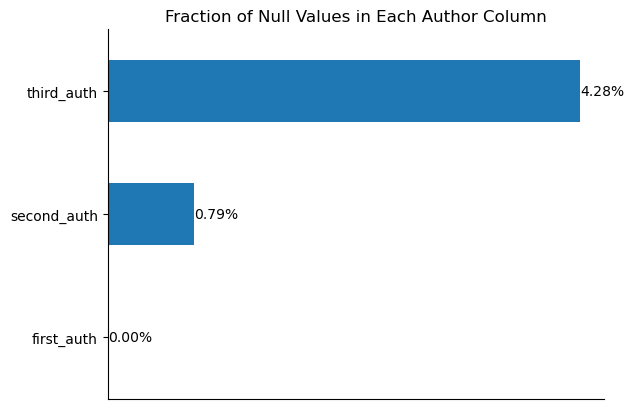

In [110]:
sum_ser = papers_df_full.loc[:, ['first_auth', 'second_auth', 'third_auth']].isna().sum()
cts_ser = papers_df_full.loc[:, ['first_auth', 'second_auth', 'third_auth']].isna().count()

ax = ((sum_ser/cts_ser)*100).plot(kind = 'barh')

# Remove the right, top, and bottom spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Remove x-axis ticks, tick labels and axis label
ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax.set_xlabel('')

ax.set_title('Fraction of Null Values in Each Author Column')

for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%')


From this distribution, we see that about 5% of rows have null values for `third_auth` and a little over 1% have null values for `second_auth`. In contrast, none of the rows have null values for `first_author`, which is encouraging that the author expansion method worked adequately. Since all the rows with null values for `third_auth` likely have null values for `second_auth`, and these rows only represent about 5% of the data set, let's drop the rows where there are null values for `third_auth`.

In [70]:
papers_df_full.dropna(subset = 'third_auth').isna().sum()

first_auth        0
second_auth       0
third_auth        0
entry_id          0
Cites             0
EntryTitle        0
Year              0
Source            0
GSRank            0
ECC               0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
profile_id        0
PubType           0
SJR               0
H index           0
Country           0
Region            0
dtype: int64

It looks like that removed all the null values. Let's offically drop the rows where there are null values for `third_auth` in `papers_df_full`.

In [71]:
papers_df_full = papers_df_full.dropna(subset = 'third_auth').reset_index(drop = True)

Here is the new `papers_df_full`

In [72]:
papers_df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21333 entries, 0 to 21332
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      21333 non-null  object 
 1   second_auth     21333 non-null  object 
 2   third_auth      21333 non-null  object 
 3   entry_id        21333 non-null  int64  
 4   Cites           21333 non-null  int16  
 5   EntryTitle      21333 non-null  object 
 6   Year            21333 non-null  int16  
 7   Source          21333 non-null  object 
 8   GSRank          21333 non-null  int16  
 9   ECC             21333 non-null  int16  
 10  CitesPerYear    21333 non-null  float16
 11  CitesPerAuthor  21333 non-null  int16  
 12  AuthorCount     21333 non-null  int8   
 13  profile_id      21333 non-null  int16  
 14  PubType         21333 non-null  object 
 15  SJR             21333 non-null  float64
 16  H index         21333 non-null  float64
 17  Country         21333 non-null 

### 2.1.2 Reformatting Author Names in `papers_df_full` and `profile_df`

To address authorship ambiguity in the data set, we must apply a standard string format for all the values in the author's column `papers_df_full` and the `Query` column of `profile_df`. We will use a similar formatting process done in **Section 1.5** using the following protocol:

1. Encode the string in ASCII
2. No name prefixes or suffixes (Ph.D., Dr, jr, etc.)
3. Remove any UTF-8 characters
4. All characters are lowercase

In [73]:
import re

def edit_names(name):
    
    '''
    
    Cleans up an author's name by removing non-UTF-8 characters, titles, and other
    extraneous information using regex.
    
    Parameters:
    ----------
    name: str 
        A string representing a name.

    Returns:
    -------
    str: The cleaned up name string, converted to lowercase and stripped of leading/trailing whitespace. 
    None: If the input is not a string, or if the cleaned up name string is empty, returns None.
    
    '''

        
    if isinstance(name, str):
        # remove any non-UTF-8 characters using encode method
        name = name.encode('ascii', 'ignore').decode('ascii')
        
        # remove any parenthess, hyphans and periodsusing regenx
        name = re.sub(r'[^a-zA-Z\s]', '', name).strip()

        # remove double spaces
        name = re.sub(r'  ', '', name).strip()

        # Use re to remove commas and anything after them
        name = re.sub(r'\,.*', '', name).strip()

        # Use re to remove title: Dr
        name = re.sub(r'^Dr\.?\s*', '', name).strip()

        # Use re to remove title: phd
        name = re.sub(r'^PhD\s*', '', name).strip()

        # Use re to remove phd
        name = re.sub(r'Ph\.?D\.?.*', '', name).strip()

        # Use re to remove title: Proff.
        name = re.sub(r'^PROFF\.?\s*', '', name).strip()

        # Remove the title: 'jr'
        name = re.sub(r'jr\.?s*', '', name).strip()

        # Rmove the title 'Junior'
        name = re.sub(r'junior', '', name).strip()

        # Remove 'equal contribution'
        name = re.sub(r'equal contribution', '', name).strip()

        # Remove 'ltslmw'
        name = re.sub(r'lts', '', name).strip()

        # Remove 'lmw'
        name = re.sub(r'lmw', '', name).strip()

        # Remove 'orcid'
        name = re.sub(r'ORCID:0000000160401920', '', name).strip()
        
        # remove '= equal first authors'
        name = re.sub(r' equal first authors', '', name).strip()
        
        if name != '':
            return name.lower().strip()
        else:
            return None
    else:
        return None

def edit_papers_names(row):
    
    '''
    Preps rows in `papers_df_full` for being passed into edit_names by looping over each column 
    in the given row.
    
    Parameters:
    ----------
    row: str
        A row from a Pandas DataFrame
    
    Returns:
    -------
    ret: list 
         A list containing the re-formatted author names.
    '''
    
    return [edit_names(i) for i in row]

def edit_profile_names(row):
    '''
    Preps rows in `profile_df` for being passed into edit_names for re-formatting by splitting the affiliation 
    from the author's name.
    
    Parameters:
    ----------
    row: pandas.Series
        A row from a Pandas DataFrame
    
    Returns:
    -------
    ret_val: str 
        The re-formatted name from the function
    
    '''
    # Splits affiliation from author's name
    split_col = [i.strip() for i in row['Query'].rsplit(' - ')]
    
    # author's name is the first element
    name = split_col[0]
    
    # Passing through edit_names
    ret_val = edit_names(name)
    return ret_val

First, let's format the author names in `profile_df`. In `profile_df`, the author names are stored under the column `Query`. Here is a sample of the first 5 rows of `Query` before formatting.

In [74]:
profile_df['Query'].head(5)

0               Edward Sargent - University of Toronto
1    Norbert Koch - Institut für Physik &IRIS Adler...
2    Dieter Neher - University of Potsdam, Institut...
3    Daniel Duprez - IC2MP, Université de Poitiers,...
4       Sergey Makarov - Professor, Head of Laboratory
Name: Query, dtype: object

Here we see that the name of the author and their affiliation are in one string. Therefore, before each row is formatted, the author's name needs to be separated from the affliation. This will all be done together by applying the function `edit_profile_names()` to each row in the data frame. Let's reformat the names and store the results in a new column `profile_author`.

In [75]:
profile_df = profile_df.assign(profile_author = profile_df.apply(edit_profile_names, axis = 1))

Here are the first 5 rows of the reformatting author names in `profile_author`.

In [76]:
profile_df['profile_author'].head(5)

0    edward sargent
1      norbert koch
2      dieter neher
3     daniel duprez
4    sergey makarov
Name: profile_author, dtype: object

We see that method successfully reformatted the names in `profile_df`. Since we don't expect names in `profile_df` to overlap, we can check if the reformatting step maintained the number of unique author names.

In [77]:
result = profile_df['profile_author'].value_counts().sum() == profile_df['Query'].value_counts().sum()
print('Are the number of unqiue author names maintained?\t', result)

Are the number of unqiue author names maintained?	 True


Let's perform the reformatting process on `papers_df_full`. Unlike the process done on `profile_df`, we don't have to split anything from the strings before they're reformatted, the `edit_names` function just needs to be applied to every column in the rows. This will all be done using the function `edit_papers_names`. Let's reformat the names in `papers_df_full`, but wait on overwriting the original names.

In [78]:
test_df = papers_df_full.loc[:, ['first_auth', 'second_auth', 'third_auth']].apply(edit_papers_names)

Here are the first 5 rows of the reformatted names.

In [79]:
test_df.head(5)

,first_auth,second_auth,third_auth
0,d shi,v adinolfi,r comin
1,k lin,j xing,ln quan
2,sa mcdonald,g konstantatos,s zhang
3,h tan,a jain,o voznyy
4,g konstantatos,i howard,a fischer


From this output, the reformatting was successful. However, unlike the names in `profile_df`, we expect the number of unique author names to decrease as we standardize the formatting. So, let's see if the new formatting reduced the number of unique author names.

In [80]:
def get_unique_auth(df):
    
    '''
    Given a pandas DataFrame `df` containing columns named 'first_auth', 'second_auth', and 'third_auth', this function 
    concatenates the values of these columns into a single list, creates a pandas Series from this list, and then calculates 
    the number of unique values in the Series. The function then prints the number of unique author names found in the DataFrame, 
    and returns the count as an integer.

    Parameters:
    -----------
    df : pandas.DataFrame
        A DataFrame containing columns named 'first_auth', 'second_auth', and 'third_auth', which should contain string 
        values representing author names.
    
    Returns:
    --------
    ret: int
        The count of unique author names found in the DataFrame.
    
    '''
    
    author_list = np.concatenate(df.loc[:, ['first_auth', 'second_auth', 'third_auth']].values)
    auth_ser = pd.Series(author_list)
    
    unique_names = auth_ser.unique().shape[0]
    print(f"There are {unique_names} unique author names")
    return unique_names

In [81]:
print('Before Reformatting')
before = get_unique_auth(papers_df_full)
print('---')
print('After Reformatting')
after = get_unique_auth(test_df)
print('---')
print(f'That is {before-after} additional names grouped!')

Before Reformatting
There are 20406 unique author names
---
After Reformatting
There are 16228 unique author names
---
That is 4178 additional names grouped!


From this result, we see that applying the standard formatting grouped over 4,000 names, thereby sucessfully lowering the authorship ambiguity of the data set. Let's overwrite the author names in `papers_df_full` with the reformatted names.

In [82]:
papers_df_full.loc[:, ['first_auth', 'second_auth', 'third_auth']] = test_df

Here is a sample of 5 rows of the author columns for the new `papers_df_full`:

In [83]:
papers_df_full.loc[:, ['first_auth', 'second_auth', 'third_auth']].sample(5)

,first_auth,second_auth,third_auth
15370,t moot,dr dikova,a hazarika
2568,t wu,ma zurbuchen,s saha
13392,g weng,y liu,s chen
11015,a pop,a silvestru,ej jurezprez
1546,j fonseca,n bion,ye licea


Let's check to see if there any null values in `papers_df_full` after formatting.

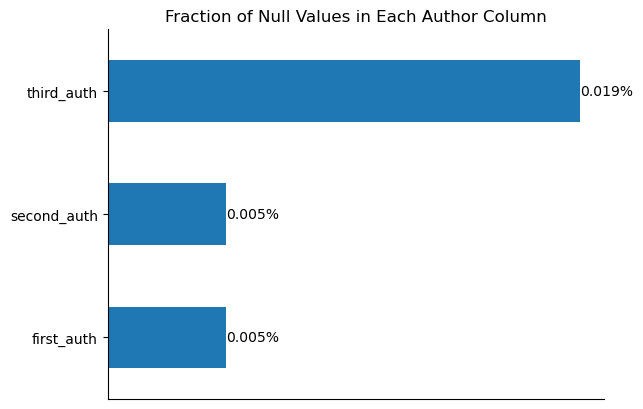

In [98]:
sum_ser = papers_df_full.loc[:, ['first_auth', 'second_auth', 'third_auth']].isna().sum()
cts_ser = papers_df_full.loc[:, ['first_auth', 'second_auth', 'third_auth']].isna().count()

ax = ((sum_ser/cts_ser)*100).plot(kind = 'barh')

# Remove the right, top, and bottom spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Remove x-axis ticks, tick labels and axis label
ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax.set_xlabel('')

ax.set_title('Fraction of Null Values in Each Author Column')

for i in ax.containers:
    ax.bar_label(i, fmt='%.3f%%')


It looks like a very small fraction (0.029%) of the rows have been converted into null values after reformatting. This is likely because the author's names were written entirely using non-latin alphabet characters, so the string was reduced to being empty. Let's see if removing the rows where the entry for `third_auth` is null will resolve the nulls.

In [111]:
papers_df_full.dropna(subset = 'third_auth').reset_index(drop = True).isna().sum()

first_auth        0
second_auth       0
third_auth        0
entry_id          0
Cites             0
EntryTitle        0
Year              0
Source            0
GSRank            0
ECC               0
CitesPerYear      0
CitesPerAuthor    0
AuthorCount       0
profile_id        0
PubType           0
SJR               0
H index           0
Country           0
Region            0
dtype: int64

It looks like that removed all the null values. Let's offically drop the rows where there are null values for `third_auth` in `papers_df_full`.

In [30]:
papers_df_full = papers_df_full.dropna(subset = 'third_auth').reset_index(drop = True)

Here is the new `papers_df_full`

In [31]:
papers_df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21329 entries, 0 to 21328
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   first_auth      21329 non-null  object 
 1   second_auth     21329 non-null  object 
 2   third_auth      21329 non-null  object 
 3   entry_id        21329 non-null  int64  
 4   Cites           21329 non-null  int16  
 5   EntryTitle      21329 non-null  object 
 6   Year            21329 non-null  int16  
 7   Source          21329 non-null  object 
 8   GSRank          21329 non-null  int16  
 9   ECC             21329 non-null  int16  
 10  CitesPerYear    21329 non-null  float16
 11  CitesPerAuthor  21329 non-null  int16  
 12  AuthorCount     21329 non-null  int8   
 13  profile_id      21329 non-null  int16  
 14  PubType         21329 non-null  object 
 15  SJR             21329 non-null  float64
 16  H index         21329 non-null  float64
 17  Country         21329 non-null 

### 2.1.3 Grouping of Author Names Across `papers_df_full` and `profile_df`

The next step in reducing the authorship ambiguity in the data set is to find unique formats of names that belong to the same author that the previous reformatting method couldn't consolidate. For example, a search of the author names in `papers_df_full` shows that the author *Edward H Sargent* is cited in the following formats:

In [32]:
author_list = np.concatenate(papers_df_full.loc[:, ['first_auth', 'second_auth', 'third_auth']].values)
ser = pd.Series(author_list)
for i in ser[ser.str.contains('sargent') == True].unique():
    print(i)

eh sargent
e sargent
eth sargent


Therefore, we need to employ a method that will be able to idetnify and group the names that refer to the same author.

Before employing this method, let's combine the author name columns in `papers_df_full` and `profile_df` into one data frame named `join_df` to consolidate the names across both data sets.

In [33]:
join_df = pd.merge(left = papers_df_full, right = profile_df[['id', 'profile_author']], left_on = 'profile_id', right_on = 'id')

In [34]:
# only want to columns with the author names
join_df = join_df.loc[:, ['first_auth', 'second_auth', 'third_auth', 'profile_author']]

Here are 4 sampled rows from `join_df`:

In [35]:
join_df.loc[[19, 63, 481, 578],:]

,first_auth,second_auth,third_auth,profile_author
19,os bushuyev,p de luna,ct dinh,edward sargent
63,br sutherland,s hoogland,mm adachi,edward sargent
481,f tan,mi saidaminov,h tan,edward sargent
578,r quinterobermudez,j kirman,d ma,edward sargent


Using names from `join_df`, there are two methods we will employ to group the author names.

**Method 1**: Grouping By Rows

The algorithm will search row-wise for names that are similar using the method `SequenceMatcher`. The name with the most amount of characters (highlighted in blue) will replace other matched names (highlighted in red). For example, since the values in `profile_author` are full names, this method will replace instances of the `profile_author` values found in the `papers_df_full` author columns.

Before replacement:

|	|first_auth|second_auth |third_auth|profile_author     |
|---|----------|------------|----------|-------------------| 
|19 |cr kagan  |e lifshitz  |<span style="color: red;"> eh sargent<span>|<span style="color: blue;">edward sargent<span>|
|63 |j yang    |<span style="color: red;">e sargent<span> |b oregan     |<span style="color: blue;">edward sargent<span>|
|481|<span style="color: red;">eh sargent<span>|gl tan	|jm xu	        |<span style="color: blue;">edward sargent<span>|
|578 |<span style="color: red;">eth sargent<span>|g tan	|jm xu          |<span style="color: blue;">edward sargent<span>|

After replacement:

|	|first_auth|second_auth |third_auth|profile_author     |
|---|----------|------------|----------|-------------------| 
|19 |cr kagan  |e lifshitz  |<span style="color: blue;">edward sargent<span>|<span style="color: blue;">edward sargent<span>|
|63 |j yang    |<span style="color: blue;">edward sargent<span>|b oregan     |<span style="color: blue;">edward sargent<span>|
|481|<span style="color: blue;">edward sargent<span>|gl tan	|jm xu	        |<span style="color: blue;">edward sargent<span>|
|578 |<span style="color: blue;">edward sargent<span>|g tan	|jm xu          |<span style="color: blue;">edward sargent<span>|

**Method 2**: Grouping by `profile_author`

The algorithm will search all the author values for data frames grouped by `profile_author` to find names that are similar using the method `SequenceMatcher`. The name with the most amount of characters (highlighted in blue) will replace other matched names (highlighted in red). 

Before replacement:

|	|first_auth    |second_auth    |third_auth|profile_author     |
|---|--------------|---------------|----------|-------------------| 
|19 |cr kagan      |e lifshitz     |edward sargent|edward sargent|
|63 |j yang        |edward sargent |b oregan     |edward sargent|
|481|edward sargent|<span style="color: blue;">gl tan<span>	|jm xu	        |edward sargent|
|578|edward sargent|<span style="color: red;">g tan<span>	|jm xu          |edward sargent|

After replacement:

|	|first_auth    |second_auth    |third_auth|profile_author     |
|---|--------------|---------------|----------|-------------------| 
|19 |cr kagan      |e lifshitz     |edward sargent|edward sargent|
|63 |j yang        |edward sargent |b oregan     |edward sargent|
|481|edward sargent|<span style="color: blue;">gl tan<span>	|jm xu	        |edward sargent|
|578|edward sargent|<span style="color: blue;">gl tan<span>	|jm xu          |edward sargent|

To achieve these matches, we must determine a threshold value for `SequenceMatcher` to determine if the names refer to the same person. Using the Edward Sargent example, we find the name variations have the following match percentages:

In [36]:
name_samples = ['eh sargent', 'e sargent', 'eth sargent', 'edward sargent']

print('Name 1\tName 2\tMatch Percent')
print('-----------------------------')
for i in range(len(name_samples)):
    for j in range(i,len(name_samples)):
        a = name_samples[i]
        b = name_samples[j]
        if a!= b:
            r = SequenceMatcher(None, a, b).ratio()
            format_ = '{}\t{}\t{:0.2%}'.format(a,b,r)
            print(format_)

Name 1	Name 2	Match Percent
-----------------------------
eh sargent	e sargent	94.74%
eh sargent	eth sargent	95.24%
eh sargent	edward sargent	75.00%
e sargent	eth sargent	90.00%
e sargent	edward sargent	78.26%
eth sargent	edward sargent	72.00%


We find that the threshold must be at most 70% for all formatting variations to match. However, this threshold would also consider these names referring to the same person, even though they have different first initials and last names as shown below:

In [37]:
name_samples = ['s zhang', 'l zhang', 'j shang', 'j huang']

print('Name 1\tName 2\tMatch Percent')
print('-----------------------------')
for i in range(len(name_samples)):
    for j in range(i,len(name_samples)):
        a = name_samples[i]
        b = name_samples[j]
        if a!= b:
            r = SequenceMatcher(None, a, b).ratio()
            format_ = '{}\t{}\t{:0.2%}'.format(a,b,r)
            print(format_)

Name 1	Name 2	Match Percent
-----------------------------
s zhang	l zhang	85.71%
s zhang	j shang	71.43%
s zhang	j huang	71.43%
l zhang	j shang	71.43%
l zhang	j huang	71.43%
j shang	j huang	85.71%


One method to prevent strings with different first initials and last names is to check if the first two letters of the last name and the first inital are the same. However, this would also group names with the same first names but different middle initials together.

In [38]:
name_samples = ['ty wu','tz wu']

print('Name 1\tName 2\tMatch Percent')
print('-----------------------------')
for i in range(len(name_samples)):
    for j in range(i,len(name_samples)):
        a = name_samples[i]
        b = name_samples[j]
        if a!= b:
            r = SequenceMatcher(None, a, b).ratio()
            format_ = '{}\t{}\t{:0.2%}'.format(a,b,r)
            print(format_)

Name 1	Name 2	Match Percent
-----------------------------
ty wu	tz wu	80.00%


Therefore, we need to also implement a conditional statement that checks if names with the `papers_df_full` formatting have matching middle initials before checking the match percentage. However, in order for names such as `eh sargent`and `eth sargent` to be considered as a match, checking for middle initials must be optional depending on the type of matching that is to be done. Deciding whether or not checking for middle initials is necessary can be based on if either **Method 1** or **Method 2** is employed. 

Since **Method 1** check for matches row wise, it will consider a group of names with size 4. Therefore, it is more likely that names with a 70% sequence match to be referring to the same author.

In contrast, **Method 2** checks for matches by `profile_author` groups, which consist of up to 3,000 unique names. Therefore, it is less likely that names with a 70% sequence match to be referring to the same author, so the middle initial checker would be employed.

To perform name-matching, we will apply both **Method 1** and **Method 2** to the author names in join_df. This will ensure that any author (first, second, or third) whose name matches the profile_name will be replaced by `profile_author` first. Next, **Method 2** will group names by `profile_author` and match those with the same first, middle, and last initials. We will repeat this process five times to identify matches that may have been missed by **Method 1**, but become recognizable after applying **Method 2**.

The diagram below illustrates the path taken by the function `match_names`, which will match names depending on which method is called. 


*Please visit [this link](https://viewer.diagrams.net/?highlight=0000ff&nav=1&title=match_pairs#Uhttps%3A%2F%2Fdrive.google.com%2Fuc%3Fid%3D1uvDVrko0aGnqavecmTQbY5TWpwhrQKLg%26export%3Ddownload) if the embedded image is not shown.*

In [39]:
from IPython.display import IFrame
IFrame('https://viewer.diagrams.net/?highlight=0000ff&nav=1&title=match_pairs#Uhttps%3A%2F%2Fdrive.google.com%2Fuc%3Fid%3D1uvDVrko0aGnqavecmTQbY5TWpwhrQKLg%26export%3Ddownload', width=1000, height=700)

Let's apply these methods to `join_df` to see how much authorship ambiguity is resolved. 

In [40]:
def all_same(itemlist):
    '''
    Determines if all elements in the input list are the same.

    Parameters:
    ---------
    itemlist: list
        A list of items to check for equality.

    Returns:
    -------
    ret: bool
        True if all elements in the input list are the same, False otherwise.
    '''
    return all(x == itemlist[0] for x in itemlist)
        
def match_names(row, v = 'v1', col = None, token_state = 'on', input_ratio = 0.70):
    
    '''
    For each title in the data set, checks if there is more than one citation. If there is, checks
    if the names are formatted in the same way using SequnceMatcher (ratio testing) or by checking if names
    have the same initials. 
    
    If the names are not the same, returns the variation of the name that is the longest.

    Parameters:
    ---------
    row: pandas.Series
        The input row to be processed.
    v: str (default = 'v1') 
        The version of the function to use.
    col: str or None (default = None)
        The name of the column to group the rows by.
    token_state: str (default = 'on')
        The state of the tokenization function. If 'on', then ratio testing is only allowed if the middle initials
        of the name pairs match.
    input_ratio: float (default = 0.70)
        The minimum similarity ratio for names.

    Returns:
        dict or bool: A dictionary of names to be replaced, or False if no replacements are necessary.

    '''
    if v == 'v1':
        # for grouping row-wise
        og_vals = row
    elif v == 'v2':
        # for grouping by profile_author
        og_vals = row[col].values
    
    # Initiates a list of unique names
    new_vals = np.unique([i for i in og_vals if isinstance(i, str)])
    
    # Split the names into initials, first and last names
    last_names = [i.rsplit(' ')[-1] for i in new_vals] # make a list of the last names
    first_initial = [i.rsplit(' ')[0][0] for i in new_vals] # make a list of the first initial
    middle_initial = [i.rsplit(' ')[0][1] if len(i.rsplit(' ')[0]) > 1 else 'None' for i in new_vals] #make list of last initials
    last_initial = [i.rsplit(' ')[-2:][0] for i in new_vals] # make a list of the last initial
    
    # Initiate Dictionary of Replacement Names
    replace_dic = {}
    
    # Looping over news in list
    for i in range(0, len(new_vals)):

        for j in range(i+1, len(new_vals)):

            a = new_vals[i]
            b = new_vals[j]

            # Split the names into initials
            first_initial_a, middle_initial_a, last_a, last_initial_a = first_initial[i], middle_initial[i], last_names[i], last_initial[i]
            first_initial_b, middle_initial_b, last_b, last_initial_b = first_initial[j], middle_initial[j], last_names[j], last_initial[j]

            # If first and first two letters in last name match
            if last_initial_a == last_initial_b and\
                first_initial_a == first_initial_b:

                # If token tag is on, only allow ratio testing if middle initials match
                if token_state == 'on':
                    if middle_initial_a == middle_initial_b:
                        ratio_tag = True
                    else:
                        ratio_tag = False

                # If token tag is off, allow ratio testing
                elif token_state == 'off':
                    ratio_tag = True

                # Perform Ratio Testing
                if ratio_tag == True:

                    r = SequenceMatcher(None, a, b).ratio()

                    if r > input_ratio: # if the names are at least x% similar

                        name = [a,b]
                        # Replace the name with the least number of characters with the name with the most characters
                        name.sort(reverse = False, key = len)
                        replace_dic.update({name[0] : name[1]})
            else:
                # If first and last initials don't match, skip this pair
                pass

    #If replace_dic is not empty, return the dictionary
    if len(replace_dic) != 0: 
        return replace_dic
    #If replace_dic is empty, return False
    else:
        return False

In [41]:
def row_wise(df):
    
    '''
    Compare names row-wise in a DataFrame and generate a replacement dictionary for similar names.
    token_tag = 'off', meaning middle initals are NOT checked before checking sequnce ratios.
    
    Parameters:
    ----------
    df: pandas.DataFrame
        A DataFrame containing the columns 'first_auth', 'second_auth', 'third_auth', and 'profile_author'.

    Returns:
    -------
    tuple:
        A tuple containing:
        - A dictionary containing the names to be replaced and their replacements.
        - A string indicating that the comparison was done row-wise.
        - A string indicating the color to be used for plotting.

    '''
    
    #print('-- Applying Method 1 --')
    
    ## Initiate the Replacement Dictionary 
    replace_dic = {}

    # Loop over each author column
    name_arr = np.asarray(df.loc[:, ['first_auth', 'second_auth', 'third_auth', 'profile_author']])

    for i in range(name_arr.shape[0]):
        return_vals = match_names(name_arr[i, :], v = 'v1', token_state = 'off', input_ratio = 0.70)
        if return_vals:
            replace_dic.update(return_vals)
    
    return replace_dic, 'Method 1', '#0072b2'

def groupby_profileAuthor(df):
    
    '''
    Compare names by `profile_author` in a DataFrame and generate a replacement dictionary for similar names.
    token_tag = 'on', meaning middle initals are checked before checking sequnce ratios.

    Parameters:
    ----------
    df: pandas.DataFrame
        A DataFrame containing the columns 'first_auth', 'second_auth', 'third_auth', and 'profile_author'.

    Returns:
    -------
    tuple:
        A tuple containing:
        - A dictionary containing the names to be replaced and their replacements.
        - A string indicating that the comparison was done row-wise.
        - A string indicating the color to be used for plotting.

    '''
    
    #print('-- Applying Method 2 --')
    
    # 1. Initiate the Replacement Dictionary 
    replace_dic = {}
    
    # 2. Loop over each group of profile author grouop
    for group_label, group_indices in join_df.groupby('profile_author').groups.items():
        group = join_df.iloc[group_indices]
        name_arr = np.concatenate(group.values)
        return_vals = match_names(name_arr, v = 'v1', col = i, token_state = 'on', input_ratio = 0.70)
        if return_vals:
            replace_dic.update(return_vals) 
            
    return replace_dic, 'Method 2', '#d55e00'

In [42]:
# Initialize iteration counter
j = 0

# Define columns related to author names and a subset of those columns for iteration
auth_cols = ['first_auth', 'second_auth', 'third_auth', 'profile_author']
auth_subcols = ['first_auth', 'second_auth', 'third_auth']

# Initialize a dictionary to store plotting data
plt_dic = {
    'num_auth': [],      # Stores number of unique author names
    'labels': [],        # Labels for each iteration/cycle
    'colors': [],        # Colors associated with each cycle
    'iteration': [],     # Iteration number for each cycle
    'change_first':[],   # Number of changes in 'first_auth' column
    'change_second': [], # Number of changes in 'second_auth' column
    'change_third': [],  # Number of changes in 'third_auth' column
    'change_profile': [] # Number of changes in 'profile_author' column
}

# Get initial unique author names and store the count and details for plotting
num = get_unique_auth(join_df)
plt_dic['num_auth'].append(num)
plt_dic['labels'].append('Start')      # Label for initial state
plt_dic['colors'].append('#009e73')    # Color for initial state
plt_dic['iteration'].append(j)         # Append the current iteration (0)

# Initialize set_num to zero for comparison in the loop
set_num = int()

# Set a flag to control the loop
flag = False

# Initialize 'change' values for each author column with zero for the first iteration
for key in list(plt_dic.keys())[4:]:
    plt_dic[key].append(0)

# Start a loop to perform up to 10 cycles, the loop breaks when no more changes occur
while flag == False:
   
    print('\n')
    print(f'--- Performing Cycle {j+1} ---')  # Display the current cycle number
    print('\n')
    
    # Apply each function to update author names (row-wise or grouped by profile author)
    for func in [row_wise, groupby_profileAuthor]:
        
        # Get replacement dictionary, label, and color from the function
        replace_dic, label, color = func(join_df)
        
        # Make a copy of the current DataFrame for comparison later
        compare_join_df = join_df.copy()
        
        # Apply the replacements to the author columns based on the replace_dic
        join_df.loc[:, auth_subcols] = join_df.replace(replace_dic).loc[:, auth_subcols]
        
        # Get the updated number of unique author names
        num = get_unique_auth(join_df)
        
        # Append results of this cycle to the plotting dictionary
        plt_dic['num_auth'].append(num)
        plt_dic['labels'].append(label)
        plt_dic['colors'].append(color)
        plt_dic['iteration'].append(j)
        
        # Compare the original DataFrame with the updated one to count changes
        check_df = compare_join_df.loc[:, auth_cols] == join_df.loc[:, auth_cols]
        changed_ser = check_df.count() - check_df.sum()  # Calculate the number of changes in each column
        
        # Append the change count for each author column
        ch_first, ch_second, ch_third, ch_profile = changed_ser
        plt_dic['change_first'].append(ch_first)
        plt_dic['change_second'].append(ch_second)
        plt_dic['change_third'].append(ch_third)
        plt_dic['change_profile'].append(ch_profile)
    
    # Check if the number of unique author names remains unchanged
    if set_num == num:
        flag = True  # End the loop if no changes are detected
        print("End")
    else:
        # Increment the iteration counter and update set_num to the current unique author count
        j = j + 1
        set_num = num
    
# Calculate the number of additional author names replaced per iteration
num_auth = np.asarray(plt_dic['num_auth'])
shift_arr = np.subtract(num_auth[:len(num_auth)-1], num_auth[1:])  # Calculate the difference between consecutive elements
diff_arr = np.append(0, shift_arr)  # Append 0 to match the array length
plt_dic['repl_auth'] = diff_arr  # Store the number of replaced author names for each step


There are 16226 unique author names


--- Performing Cycle 1 ---




There are 16176 unique author names
There are 15296 unique author names


--- Performing Cycle 2 ---


There are 15272 unique author names
There are 15066 unique author names


--- Performing Cycle 3 ---


There are 15051 unique author names
There are 14962 unique author names


--- Performing Cycle 4 ---


There are 14958 unique author names
There are 14925 unique author names


--- Performing Cycle 5 ---


There are 14923 unique author names
There are 14916 unique author names


--- Performing Cycle 6 ---


There are 14916 unique author names
There are 14914 unique author names


--- Performing Cycle 7 ---


There are 14914 unique author names
There are 14913 unique author names


--- Performing Cycle 8 ---


There are 14913 unique author names
There are 14913 unique author names
End


Reduction is authorship ambiguity 7.81%


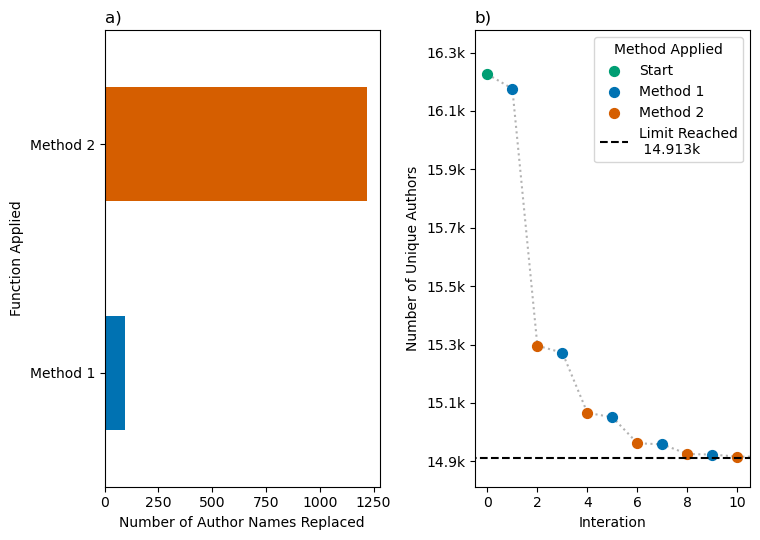

In [43]:
group_auth_df = pd.DataFrame(plt_dic)
group_auth_df = group_auth_df[group_auth_df['labels'] != 'Start']

fig, axes = plt.subplots(1, 2, figsize = (7.7, 5.5))

ax = axes[0]
colors = group_auth_df.groupby('labels')['colors'].apply(list).str[0].values.tolist()
bar_plot = group_auth_df.groupby('labels')['repl_auth'].sum().plot(kind = 'barh', color = colors, ax = ax)

bar_plot.set_title('a)', loc = 'left')
bar_plot.set_xlabel('Number of Author Names Replaced')
bar_plot.set_ylabel('Function Applied')


ax = axes[1]
colors = plt_dic['colors']
num_authors = plt_dic['num_auth']
labels = plt_dic['labels']

for i in range(len(num_authors)):
    ax.scatter(i, num_authors[i], label = labels[i], color = colors[i], marker = 'o', s = 50)

# Final number of unqiue authors
min_authors = group_auth_df['num_auth'].min()
max_authors = group_auth_df['num_auth'].max()

ax.plot(num_authors, color = 'grey', ls = 'dotted', zorder = 0, alpha = 0.6)
ax.hlines(y = min_authors, xmin = -10, xmax = 20, 
          color = 'black', 
          ls = 'dashed', 
          label = f'Limit Reached\n {(min_authors/1000):.3f}k')
ax.set_xlabel('Interation')
ax.set_xlim([-0.5, 10.5])

y_ticks = np.arange(14900, 16500, 200)
y_labels = [f'{i/1000}k' for i in y_ticks]
ax.set_yticks(y_ticks, y_labels)
ax.set_ylim([min_authors - 100, max_authors + 200])
ax.set_ylabel('Number of Unique Authors')

ax.set_title('b)', loc = 'left')
container, label = ax.get_legend_handles_labels()
ax.legend(np.append(container[:3], container[-1]), np.append(label[:3], label[-1]), title = 'Method Applied', )


fig.tight_layout()

print("Reduction is authorship ambiguity", f"{((max_authors - min_authors)/max_authors):.2%}")

The reformatting procedure reduced the number of unique author names in the dataset from 16,226 to 14,913 after 8 cycles, decreasing authorship ambiguity by 7.81%. **Method 2** proved more effective at reducing this ambiguity compared to **Method 1**, likely due to its access to a larger sample size of names. Overall, we demonstrated a method that successfully reduces authorship ambiguity by leveraging the name formatting structure to maximize the likelihood of correctly identifying the same person across different entries.

Let's now overwrite the author names in `papers_df_full` with the newly formatted values in `join_df`.

In [44]:
papers_df_full.loc[:, ['first_auth', 'second_auth', 'third_auth']] = join_df.loc[:, ['first_auth', 'second_auth', 'third_auth']]

---

## 2.2 Additional Data Set Cleaning

The objective of **Section 2.2** is to apply further data set cleaning. Another method of reducing authorship ambiguity is by removing duplicated citation entries from the data set. While analysis done in **Notebook 1** confirmed there were no duplicated entries, this may have changed after the formatting of the author's names have changed.

In [45]:
papers_df_full = papers_df_full.drop('entry_id', axis = 1).reset_index(drop = False).rename(columns = {'index': 'entry_id'})

In [46]:
print('Duplicated Entries Based on All Columns', papers_df_full.duplicated().sum())
print('Duplicated Entries Based on Title and Authors', papers_df_full.duplicated(['EntryTitle', 'first_auth', 'second_auth', 'third_auth']).sum())

Duplicated Entries Based on All Columns 0
Duplicated Entries Based on Title and Authors 5218


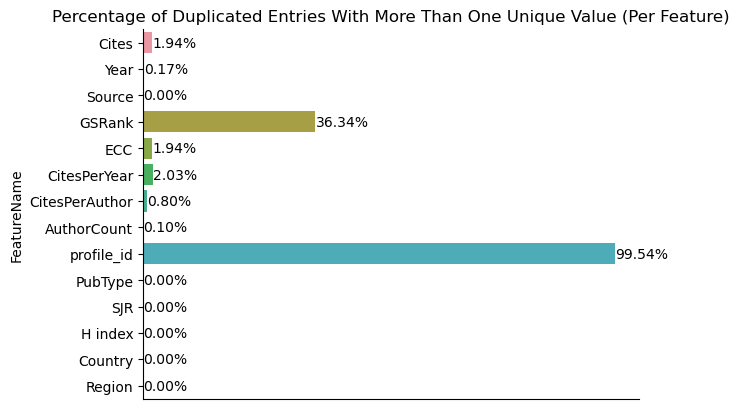

In [54]:
# Filter the rows that are duplicated based on 'EntryTitle', 'first_auth', 'second_auth', and 'third_auth'
duplicated_df = papers_df_full[papers_df_full.duplicated(['EntryTitle', 'first_auth', 'second_auth', 'third_auth'], keep = False)]

# Total number of duplicate rows
duplicated_num = papers_df_full.duplicated(['EntryTitle', 'first_auth', 'second_auth', 'third_auth']).sum()

# Group the duplicated entries by the same columns and calculate the number of unique values in each column,
unique_cols = (
    duplicated_df
    .groupby(['EntryTitle', 'first_auth', 'second_auth', 'third_auth'])
    .nunique()
    .reset_index(drop=True)
    .select_dtypes(include=['number'])
)

# Calculate the proportion of unique values in each numeric column by summing across rows (transpose to sum),
plt_df = (
    (((unique_cols - 1).drop('entry_id', axis=1).T.sum(axis=1) / duplicated_num)*100)
    .reset_index(drop=False)
    .rename(columns={'index': "FeatureName", 0: "Frequency"})
)

# Plot the proportion of unique values for each feature using a barplot
ax = sns.barplot(data=plt_df, x="Frequency", y="FeatureName")

# Remove the right, top, and bottom spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Remove x-axis ticks, tick labels and axis label
ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
ax.set_xlabel('')

ax.set_title("Percentage of Duplicated Entries With More Than One Unique Value (Per Feature)")

for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%')

The distribution above shows that over 99% of entries with the same title and authors have duplicates due to unique values of `profile_id`. This is expected, as the same paper can appear in the publications of multiple Google Scholar profiles. Additionally, 36% of duplicate entries are caused by unique values of `GSRank`, which is specific to the profile under which the entry is listed. The presence of unique values in `Cites`, `Year`, `CitesPerYear`, `CitesPerAuthor`, and `ECC` (under 5% each) may indicate outdated information. Therefore, the entry with the highest `Cites` value will be retained.

In [48]:
# Filter papers_df_full to remove duplicates based on the values in 'Cities' 
test_df = papers_df_full.loc[papers_df_full.groupby(['EntryTitle', 'first_auth', 'second_auth', 'third_auth'])['Cites'].idxmax()].copy()

# Check for duplicates
print('Duplicated Entries Based on Title and Authors', test_df.duplicated(['EntryTitle', 'first_auth', 'second_auth', 'third_auth']).sum())

Duplicated Entries Based on Title and Authors 0


In [49]:
print("Number of entries in DataFrame:", test_df.shape[0])
print(f"{(test_df.shape[0]/papers_df_full.shape[0])*100:.2f}% of entries kept.")

Number of entries in DataFrame: 16111
75.54% of entries kept.


After removing duplicates, over 75% of the entries were maintained, resulting in over 16,000 entries remianing in the Dataframe. This should continue to be sufficent as a machine learning data set. Let's pickle the newest version of `papers_df_full`.

In [50]:
test_df.to_pickle('output/NB2_papers_df_full.pkl')

In [117]:
# Calculate the final reduction of authorship ambuguity
aa = (before - get_unique_auth(test_df))/before

print(f"Authorship Ambiguity was reduced overall by {aa*100:.2f}%")

There are 16228 unique author names
Authorship Ambiguity was reduced overall by 20.47%


---

# Conclusion

In this notebook, we addressed the critical issue of *authorship ambiguity* by applying various feature engineering techniques to standardize author names across the dataset, thereby reducing the ambiguity by 20.47%. By splitting and formatting the `Authors` column, we ensured that inconsistent author name representations were minimized, enabling more accurate grouping and calculation of co-author metrics These steps are essential for the accuracy of the machine learning models that follow, which will classify publications into journal tiers based on these cleaned author metrics.